In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "learntwin_student_interactions.csv"
)

questions_df = pd.read_csv(
    "learntwin_questions.csv"
)

print("Interactions shape:", df.shape)
print("Questions shape:", questions_df.shape)

Interactions shape: (10000, 10)
Questions shape: (500, 3)


In [3]:
print("Interaction columns:")
print(df.columns.tolist())

print("\nQuestion columns:")
print(questions_df.columns.tolist())

Interaction columns:
['student_id', 'attempt', 'question_id', 'concept', 'difficulty', 'correct', 'time_gap_days', 'days_since_practice', 'timestamp', 'knowledge_state']

Question columns:
['question_id', 'concept', 'difficulty']


In [4]:
print("\nFirst 5 interactions:")
display(df.head())


First 5 interactions:


,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


In [5]:
students = sorted(
    df["student_id"].unique()
)

print(
    "Number of students:",
    len(students)
)

print(
    "Available students:",
    students[:20]
)

Number of students: 100
Available students: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010', 'S011', 'S012', 'S013', 'S014', 'S015', 'S016', 'S017', 'S018', 'S019', 'S020']


In [6]:
selected_student = students[0]

print(
    "Selected Student:",
    selected_student
)

Selected Student: S001


In [7]:
student_df = df[
    df["student_id"] == selected_student
].copy()

student_df = student_df.sort_values(
    "attempt"
).reset_index(drop=True)

print(
    "Student:",
    selected_student
)

print(
    "Number of attempts:",
    len(student_df)
)

display(
    student_df.head()
)

Student: S001
Number of attempts: 100


,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


In [8]:
student_accuracy = (
    student_df["correct"].mean()
)

print(
    "Student Accuracy:",
    round(student_accuracy * 100, 2),
    "%"
)

Student Accuracy: 29.0 %


##  Calculate concept-wise performance

In [9]:
concept_performance = (
    student_df
    .groupby("concept")["correct"]
    .agg(
        attempts="count",
        accuracy="mean"
    )
    .sort_values("accuracy")
)

concept_performance["accuracy"] = (
    concept_performance["accuracy"] * 100
)

display(concept_performance)

,attempts,accuracy
concept,,
HAVING,3,0.000000
LEFT JOIN,3,0.000000
JOINS,4,0.000000
RIGHT JOIN,7,0.000000
TRANSACTIONS,2,0.000000
TRIGGERS,6,0.000000
VIEWS,8,12.500000
INNER JOIN,6,16.666667
GROUP BY,5,20.000000


## Identify weak concepts

In [10]:
weak_concepts = concept_performance[
    concept_performance["accuracy"] < 50
]

print("========== WEAK CONCEPTS ==========")

display(weak_concepts)

========== WEAK CONCEPTS ==========


,attempts,accuracy
concept,,
HAVING,3,0.000000
LEFT JOIN,3,0.000000
JOINS,4,0.000000
RIGHT JOIN,7,0.000000
TRANSACTIONS,2,0.000000
TRIGGERS,6,0.000000
VIEWS,8,12.500000
INNER JOIN,6,16.666667
GROUP BY,5,20.000000


## strong concepts

In [11]:
strong_concepts = concept_performance[
    concept_performance["accuracy"] >= 70
]

print("========== STRONG CONCEPTS ==========")

display(strong_concepts)

========== STRONG CONCEPTS ==========


,attempts,accuracy
concept,,
ORDER BY,4,100.0


## Student Knowledge State

In [12]:
# Student Knowledge State

knowledge_profile = (
    student_df.groupby("concept")["correct"]
    .mean()
    .reset_index()
)

knowledge_profile["knowledge_state"] = (
    knowledge_profile["correct"] * 100
)

knowledge_profile = knowledge_profile[
    ["concept", "knowledge_state"]
].sort_values(
    "knowledge_state",
    ascending=False
)

print("Student Knowledge Profile:")
display(knowledge_profile)

Student Knowledge Profile:


,concept,knowledge_state
9,ORDER BY,100.000000
17,UNION,66.666667
10,PRIMARY KEY,57.142857
8,NORMALIZATION,50.000000
13,STORED PROCEDURES,50.000000
19,WHERE,50.000000
0,AGGREGATE FUNCTIONS,40.000000
12,SELECT,28.571429
14,SUBQUERIES,25.000000
4,INDEXING,25.000000


## Visualize Knowledge State

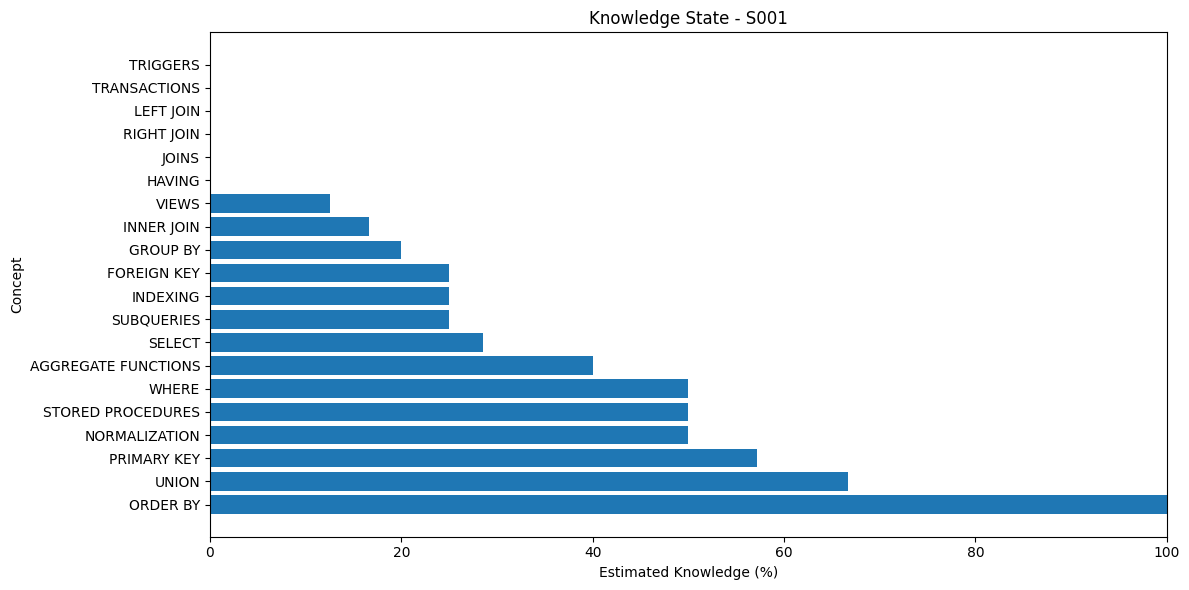

In [13]:
plt.figure(figsize=(12, 6))

plt.barh(
    knowledge_profile["concept"],
    knowledge_profile["knowledge_state"]
)

plt.xlabel("Estimated Knowledge (%)")
plt.ylabel("Concept")
plt.title(f"Knowledge State - {selected_student}")

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [14]:
def knowledge_category(score):
    if score < 50:
        return "Weak"
    elif score < 70:
        return "Developing"
    else:
        return "Strong"


knowledge_profile["category"] = (
    knowledge_profile["knowledge_state"]
    .apply(knowledge_category)
)

display(knowledge_profile)

,concept,knowledge_state,category
9,ORDER BY,100.000000,Strong
17,UNION,66.666667,Developing
10,PRIMARY KEY,57.142857,Developing
8,NORMALIZATION,50.000000,Developing
13,STORED PROCEDURES,50.000000,Developing
19,WHERE,50.000000,Developing
0,AGGREGATE FUNCTIONS,40.000000,Weak
12,SELECT,28.571429,Weak
14,SUBQUERIES,25.000000,Weak
4,INDEXING,25.000000,Weak


In [15]:
category_counts = knowledge_profile["category"].value_counts()

print("Knowledge Categories:")
display(category_counts)

Knowledge Categories:


category
Weak          14
Developing     5
Strong         1
Name: count, dtype: int64

## Knowledge Distribution

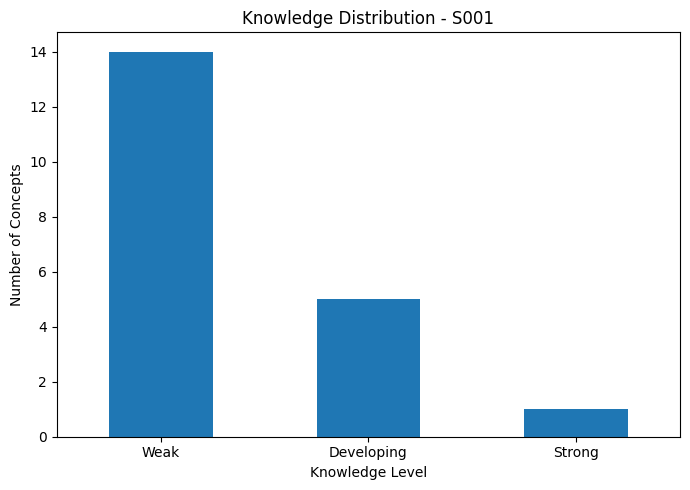

In [16]:
plt.figure(figsize=(7, 5))

category_counts.plot(
    kind="bar"
)

plt.xlabel("Knowledge Level")
plt.ylabel("Number of Concepts")
plt.title(f"Knowledge Distribution - {selected_student}")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Forgetting Risk

In [17]:
# Step 8.15 - Days Since Last Practice

last_practice = (
    student_df.groupby("concept")["days_since_practice"]
    .max()
    .reset_index()
)

last_practice = last_practice.sort_values(
    "days_since_practice",
    ascending=False
)

print("Days Since Last Practice:")
display(last_practice)

Days Since Last Practice:


,concept,days_since_practice
15,TRANSACTIONS,104.227
13,STORED PROCEDURES,88.178
1,FOREIGN KEY,78.928
6,JOINS,64.480
5,INNER JOIN,63.085
3,HAVING,58.932
2,GROUP BY,58.691
8,NORMALIZATION,57.752
4,INDEXING,56.171
0,AGGREGATE FUNCTIONS,55.025


## Prepare Forgetting Prediction Data

In [19]:
import joblib

# Load trained forgetting prediction model
forgetting_model = joblib.load("learntwin_forgetting_model.pkl")

print("Forgetting model loaded successfully!")
print(forgetting_model)

Forgetting model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['concept']),
                                                 ('numerical', 'passthrough',
                                                  ['difficulty',
                                                   'time_gap_days',
                                                   'days_since_practice',
                                                   'student_prior_attempts',
                                                   'student_prior_accuracy',
                                                   'concept_prior_attempts',
                                                   'concept_prior_accuracy'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


In [20]:
print("Model features:")

if hasattr(forgetting_model, "feature_names_in_"):
    print(forgetting_model.feature_names_in_)
else:
    print("Feature names are not stored in the model.")

Model features:
['concept' 'difficulty' 'time_gap_days' 'days_since_practice'
 'student_prior_attempts' 'student_prior_accuracy'
 'concept_prior_attempts' 'concept_prior_accuracy']


In [24]:
# Step 8.17 - Prepare data for forgetting prediction

clean_student_df = student_df.dropna(subset=["concept"]).copy()
clean_student_df = clean_student_df.sort_values("attempt")

forgetting_input = []

for concept in clean_student_df["concept"].unique():

    concept_history = clean_student_df[
        clean_student_df["concept"] == concept
    ].sort_values("attempt")

    # Latest attempt for this concept
    latest = concept_history.iloc[-1]

    # All attempts BEFORE the latest attempt
    prior_student_history = clean_student_df[
        clean_student_df["attempt"] < latest["attempt"]
    ]

    # Concept attempts before latest attempt
    prior_concept_history = concept_history[
        concept_history["attempt"] < latest["attempt"]
    ]

    # Student prior statistics
    student_prior_attempts = len(prior_student_history)

    if student_prior_attempts > 0:
        student_prior_accuracy = (
            prior_student_history["correct"].mean()
        )
    else:
        student_prior_accuracy = 0

    # Concept prior statistics
    concept_prior_attempts = len(prior_concept_history)

    if concept_prior_attempts > 0:
        concept_prior_accuracy = (
            prior_concept_history["correct"].mean()
        )
    else:
        concept_prior_accuracy = 0

    forgetting_input.append({
        "concept": concept,
        "difficulty": latest["difficulty"],
        "time_gap_days": latest["time_gap_days"],
        "days_since_practice": latest["days_since_practice"],
        "student_prior_attempts": student_prior_attempts,
        "student_prior_accuracy": student_prior_accuracy,
        "concept_prior_attempts": concept_prior_attempts,
        "concept_prior_accuracy": concept_prior_accuracy
    })

forgetting_input = pd.DataFrame(forgetting_input)

print("Forgetting prediction input:")
display(forgetting_input)

Forgetting prediction input:


,concept,difficulty,time_gap_days,days_since_practice,student_prior_attempts,student_prior_accuracy,concept_prior_attempts,concept_prior_accuracy
0,RIGHT JOIN,0.600,0.475,47.727,80,0.337500,6,0.000000
1,UNION,0.384,1.439,53.190,56,0.321429,2,0.500000
2,WHERE,0.430,0.634,20.863,84,0.321429,9,0.555556
3,STORED PROCEDURES,0.717,0.431,16.195,75,0.333333,3,0.666667
4,GROUP BY,0.355,0.816,7.313,65,0.353846,4,0.250000
5,TRIGGERS,0.746,0.167,3.368,93,0.301075,5,0.000000
6,SUBQUERIES,0.835,2.690,19.715,63,0.349206,3,0.333333
7,LEFT JOIN,0.482,0.045,38.887,49,0.326531,2,0.000000
8,VIEWS,0.618,1.903,20.102,89,0.314607,7,0.142857
9,ORDER BY,0.241,0.842,37.258,88,0.306818,3,1.000000


## Generate Forgetting Predictions

In [25]:
# Step 8.18 - Predict forgetting probability

forgetting_input["forgetting_probability"] = (
    forgetting_model.predict_proba(
        forgetting_input
    )[:, 1]
)

forgetting_input = forgetting_input.sort_values(
    "forgetting_probability",
    ascending=False
).reset_index(drop=True)

display(
    forgetting_input[
        [
            "concept",
            "days_since_practice",
            "forgetting_probability"
        ]
    ]
)

,concept,days_since_practice,forgetting_probability
0,TRANSACTIONS,104.227,0.965752
1,UNION,53.190,0.731926
2,RIGHT JOIN,47.727,0.675587
3,ORDER BY,37.258,0.636377
4,SUBQUERIES,19.715,0.615356
5,JOINS,21.402,0.615172
6,LEFT JOIN,38.887,0.603387
7,HAVING,29.845,0.603047
8,SELECT,23.441,0.509396
9,VIEWS,20.102,0.495996


In [26]:
print("Model classes:", forgetting_model.classes_)

Model classes: [0 1]


## Create Forgetting Risk Levels

In [27]:
# Step 8.20 - Categorize forgetting risk

def risk_level(probability):
    if probability >= 0.60:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"


forgetting_input["risk_level"] = (
    forgetting_input["forgetting_probability"]
    .apply(risk_level)
)

display(
    forgetting_input[
        [
            "concept",
            "days_since_practice",
            "forgetting_probability",
            "risk_level"
        ]
    ]
)

,concept,days_since_practice,forgetting_probability,risk_level
0,TRANSACTIONS,104.227,0.965752,High
1,UNION,53.190,0.731926,High
2,RIGHT JOIN,47.727,0.675587,High
3,ORDER BY,37.258,0.636377,High
4,SUBQUERIES,19.715,0.615356,High
5,JOINS,21.402,0.615172,High
6,LEFT JOIN,38.887,0.603387,High
7,HAVING,29.845,0.603047,High
8,SELECT,23.441,0.509396,Medium
9,VIEWS,20.102,0.495996,Medium


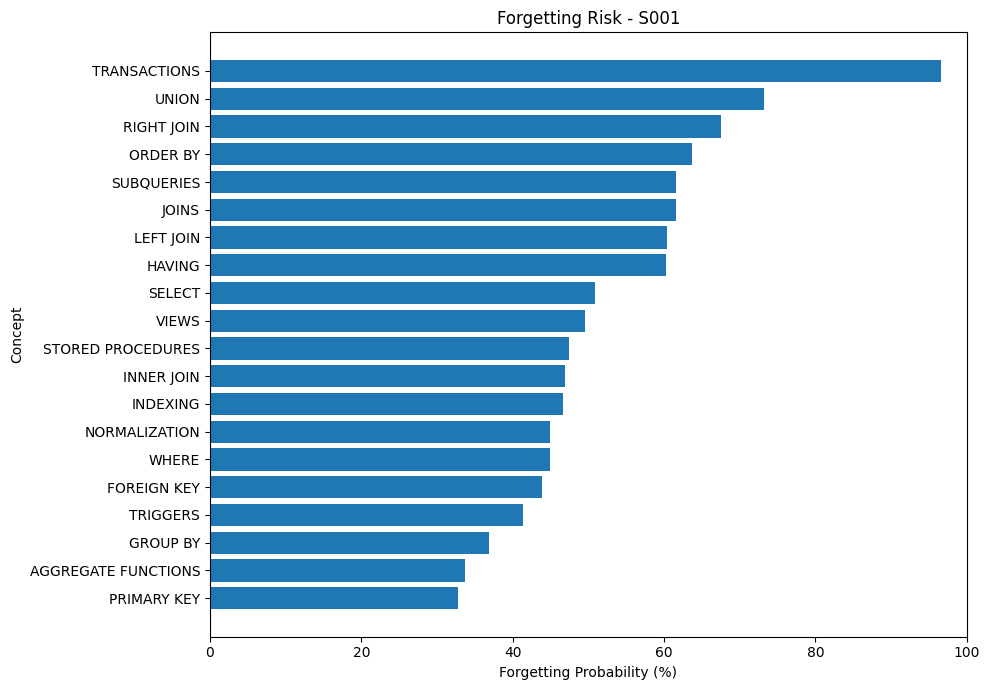

In [28]:
# Step 8.21 - Forgetting risk visualization

risk_plot = forgetting_input.sort_values(
    "forgetting_probability",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    risk_plot["concept"],
    risk_plot["forgetting_probability"] * 100
)

plt.xlabel("Forgetting Probability (%)")
plt.ylabel("Concept")
plt.title(f"Forgetting Risk - {selected_student}")

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Combine Knowledge + Forgetting

In [29]:
# Step 8.22 - Combine knowledge and forgetting information

dashboard_profile = knowledge_profile.merge(
    forgetting_input[
        [
            "concept",
            "days_since_practice",
            "forgetting_probability",
            "risk_level"
        ]
    ],
    on="concept",
    how="left"
)

display(dashboard_profile)

,concept,knowledge_state,category,days_since_practice,forgetting_probability,risk_level
0,ORDER BY,100.000000,Strong,37.258,0.636377,High
1,UNION,66.666667,Developing,53.190,0.731926,High
2,PRIMARY KEY,57.142857,Developing,2.050,0.327731,Low
3,NORMALIZATION,50.000000,Developing,10.140,0.449495,Medium
4,STORED PROCEDURES,50.000000,Developing,16.195,0.474253,Medium
5,WHERE,50.000000,Developing,20.863,0.448921,Medium
6,AGGREGATE FUNCTIONS,40.000000,Weak,7.027,0.336455,Low
7,SELECT,28.571429,Weak,23.441,0.509396,Medium
8,SUBQUERIES,25.000000,Weak,19.715,0.615356,High
9,INDEXING,25.000000,Weak,3.540,0.466624,Medium


In [30]:
# Step 8.23 - Calculate personalized learning priority

dashboard_profile["weakness_score"] = (
    1 - dashboard_profile["knowledge_state"] / 100
)

dashboard_profile["learning_priority"] = (
    0.5 * dashboard_profile["weakness_score"]
    +
    0.5 * dashboard_profile["forgetting_probability"]
)

dashboard_profile = dashboard_profile.sort_values(
    "learning_priority",
    ascending=False
).reset_index(drop=True)

display(
    dashboard_profile[
        [
            "concept",
            "knowledge_state",
            "days_since_practice",
            "forgetting_probability",
            "risk_level",
            "learning_priority"
        ]
    ]
)

,concept,knowledge_state,days_since_practice,forgetting_probability,risk_level,learning_priority
0,TRANSACTIONS,0.000000,104.227,0.965752,High,0.982876
1,RIGHT JOIN,0.000000,47.727,0.675587,High,0.837794
2,JOINS,0.000000,21.402,0.615172,High,0.807586
3,LEFT JOIN,0.000000,38.887,0.603387,High,0.801694
4,HAVING,0.000000,29.845,0.603047,High,0.801523
5,TRIGGERS,0.000000,3.368,0.413637,Medium,0.706818
6,VIEWS,12.500000,20.102,0.495996,Medium,0.685498
7,SUBQUERIES,25.000000,19.715,0.615356,High,0.682678
8,INNER JOIN,16.666667,6.815,0.469696,Medium,0.651515
9,SELECT,28.571429,23.441,0.509396,Medium,0.611841


## Find Top Priority Concepts

In [31]:
# Step 8.24 - Top concepts requiring attention

top_priority = dashboard_profile.head(5)

print("Top concepts requiring attention:")
display(
    top_priority[
        [
            "concept",
            "knowledge_state",
            "forgetting_probability",
            "risk_level",
            "learning_priority"
        ]
    ]
)

Top concepts requiring attention:


,concept,knowledge_state,forgetting_probability,risk_level,learning_priority
0,TRANSACTIONS,0.0,0.965752,High,0.982876
1,RIGHT JOIN,0.0,0.675587,High,0.837794
2,JOINS,0.0,0.615172,High,0.807586
3,LEFT JOIN,0.0,0.603387,High,0.801694
4,HAVING,0.0,0.603047,High,0.801523


## Personalized Recommendation

In [32]:
# Step 8.25 - Inspect question bank

print("Question bank columns:")
print(questions_df.columns.tolist())

display(questions_df.head())

Question bank columns:
['question_id', 'concept', 'difficulty']


,question_id,concept,difficulty
0,Q001,INNER JOIN,0.589
1,Q002,NORMALIZATION,0.720
2,Q003,INNER JOIN,0.484
3,Q004,AGGREGATE FUNCTIONS,0.438
4,Q005,GROUP BY,0.393


In [33]:
# Step 8.26 - Recommend questions

priority_concept = top_priority.iloc[0]["concept"]
knowledge_score = top_priority.iloc[0]["knowledge_state"]

recommended_questions = questions_df[
    questions_df["concept"] == priority_concept
].copy()

print("Priority concept:", priority_concept)
print("Knowledge score:", round(knowledge_score, 2), "%")

display(recommended_questions.head(5))

Priority concept: TRANSACTIONS
Knowledge score: 0.0 %


,question_id,concept,difficulty
66,Q067,TRANSACTIONS,0.606
93,Q094,TRANSACTIONS,0.694
94,Q095,TRANSACTIONS,0.782
101,Q102,TRANSACTIONS,0.659
110,Q111,TRANSACTIONS,0.674


In [34]:
# Step 8.27 - Select suitable difficulty

if knowledge_score < 40:
    preferred_difficulty = recommended_questions["difficulty"].min()
elif knowledge_score < 70:
    preferred_difficulty = recommended_questions["difficulty"].median()
else:
    preferred_difficulty = recommended_questions["difficulty"].max()

print("Preferred difficulty:", preferred_difficulty)

Preferred difficulty: 0.523


In [35]:
recommended_questions_final = recommended_questions[
    recommended_questions["difficulty"] == preferred_difficulty
]

if len(recommended_questions_final) == 0:
    recommended_questions_final = recommended_questions

print("Recommended questions:")
display(recommended_questions_final.head(5))

Recommended questions:


,question_id,concept,difficulty
263,Q264,TRANSACTIONS,0.523


## Create Student Dashboard Summary

In [36]:
# Step 8.28 - Student dashboard summary

overall_accuracy = student_df["correct"].mean() * 100

high_risk_count = (
    dashboard_profile["risk_level"] == "High"
).sum()

medium_risk_count = (
    dashboard_profile["risk_level"] == "Medium"
).sum()

weak_count = (
    dashboard_profile["knowledge_state"] < 50
).sum()

print("=" * 50)
print("             LEARNTWIN STUDENT DASHBOARD")
print("=" * 50)

print("Student:", selected_student)
print("Total Attempts:", len(student_df))
print("Overall Accuracy:", round(overall_accuracy, 2), "%")
print("Weak Concepts:", weak_count)
print("High Forgetting Risk:", high_risk_count)
print("Medium Forgetting Risk:", medium_risk_count)

print("\nTop Priority Concepts:")
display(
    top_priority[
        [
            "concept",
            "knowledge_state",
            "forgetting_probability",
            "risk_level"
        ]
    ]
)

print("=" * 50)

             LEARNTWIN STUDENT DASHBOARD
Student: S001
Total Attempts: 100
Overall Accuracy: 29.0 %
Weak Concepts: 14
High Forgetting Risk: 8
Medium Forgetting Risk: 9

Top Priority Concepts:


,concept,knowledge_state,forgetting_probability,risk_level
0,TRANSACTIONS,0.0,0.965752,High
1,RIGHT JOIN,0.0,0.675587,High
2,JOINS,0.0,0.615172,High
3,LEFT JOIN,0.0,0.603387,High
4,HAVING,0.0,0.603047,High


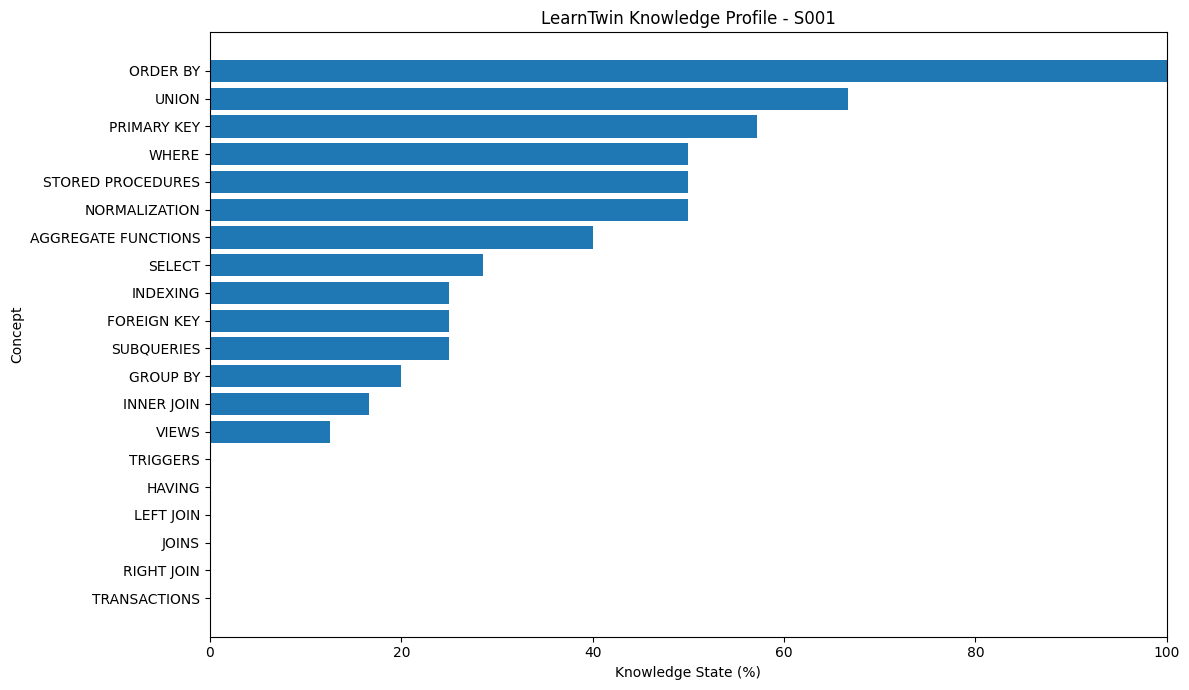

In [37]:
# Step 8.29 - Final knowledge vs forgetting dashboard

plot_data = dashboard_profile.sort_values(
    "knowledge_state"
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_data["concept"],
    plot_data["knowledge_state"]
)

plt.xlabel("Knowledge State (%)")
plt.ylabel("Concept")
plt.title(
    f"LearnTwin Knowledge Profile - {selected_student}"
)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Final Recommendation

In [38]:
# Step 8.30 - Final personalized recommendation

best_concept = top_priority.iloc[0]["concept"]

print("=" * 60)
print("             PERSONALIZED RECOMMENDATION")
print("=" * 60)

print(f"Student: {selected_student}")
print(f"Focus Concept: {best_concept}")

print(
    f"Knowledge Level: "
    f"{top_priority.iloc[0]['knowledge_state']:.2f}%"
)

print(
    f"Forgetting Probability: "
    f"{top_priority.iloc[0]['forgetting_probability']:.2f}"
)

print(
    f"Risk Level: "
    f"{top_priority.iloc[0]['risk_level']}"
)

print("\nRecommended Questions:")

display(
    recommended_questions_final.head(3)
)

print("=" * 60)

             PERSONALIZED RECOMMENDATION
Student: S001
Focus Concept: TRANSACTIONS
Knowledge Level: 0.00%
Forgetting Probability: 0.97
Risk Level: High

Recommended Questions:


,question_id,concept,difficulty
263,Q264,TRANSACTIONS,0.523


In [1]:
from pathlib import Path

# Create production folders
folders = [
    "production/models",
    "production/preprocessing",
    "production/services",
    "production/config"
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Production folders created successfully!")

for folder in folders:
    print("✅", folder)

Production folders created successfully!
✅ production/models
✅ production/preprocessing
✅ production/services
✅ production/config


In [2]:
from pathlib import Path

print("LearnTwin production structure:\n")

for path in Path("production").rglob("*"):
    if path.is_dir():
        print("📁", path)

LearnTwin production structure:

📁 production\.ipynb_checkpoints
📁 production\Config
📁 production\models
📁 production\preprocessing
📁 production\Services
📁 production\models\.ipynb_checkpoints


In [3]:
from pathlib import Path

folders = [
    "production/models",
    "production/preprocessing",
    "production/services",
    "production/config"
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("✅ Production structure created")

for folder in folders:
    print("📁", folder)

✅ Production structure created
📁 production/models
📁 production/preprocessing
📁 production/services
📁 production/config


In [5]:
from pathlib import Path

print("Current project directory:")
print(Path.cwd())

print("\nProduction directory:")

production = Path("Production")

if production.exists():
    for path in production.rglob("*"):
        print(path)
else:
    print("❌ Production folder not found")

Current project directory:
C:\Users\azads\DL_Project_folder

Production directory:
Production\.ipynb_checkpoints
Production\Config
Production\models
Production\preprocessing
Production\Services
Production\Config\forgetting_model_metadata.json
Production\models\.ipynb_checkpoints
Production\models\learntwin_forgetting_model.pkl
Production\models\learntwin_lstm_model.keras


In [6]:
print("Checking trained models...\n")

models_to_check = [
    "forgetting_model",
    "lstm_model",
    "lstm_model_v2"
]

for model_name in models_to_check:
    if model_name in globals():
        print(f"✅ {model_name} is available")
    else:
        print(f"❌ {model_name} is NOT available")

Checking trained models...

❌ forgetting_model is NOT available
❌ lstm_model is NOT available
❌ lstm_model_v2 is NOT available


In [7]:
import joblib
import tensorflow as tf

# Load the already-trained models
forgetting_model = joblib.load(
    "learntwin_forgetting_model.pkl"
)

lstm_model = tf.keras.models.load_model(
    "learntwin_lstm_model.keras"
)

print("✅ Forgetting model loaded successfully")
print("✅ LSTM model loaded successfully")

✅ Forgetting model loaded successfully
✅ LSTM model loaded successfully


In [8]:
print("========== FORGETTING MODEL ==========")
print(type(forgetting_model))
print(forgetting_model)

print("\n========== LSTM MODEL ==========")
print(type(lstm_model))
print("Input shape:", lstm_model.input_shape)
print("Output shape:", lstm_model.output_shape)

========== FORGETTING MODEL ==========
<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['concept']),
                                                 ('numerical', 'passthrough',
                                                  ['difficulty',
                                                   'time_gap_days',
                                                   'days_since_practice',
                                                   'student_prior_attempts',
                                                   'student_prior_accuracy',
                                                   'concept_prior_attempts',
                                                   'concept_prior_accuracy'])])),
                ('classifier',
                 LogisticRegression(class_we

## Check the LSTM architecture

In [9]:
print("LSTM model summary:")
lstm_model.summary()

LSTM model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ concept_input (InputLayer)    │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_embedding (Embedding) │ (None, 10, 16)            │             320 │ concept_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_input (InputLayer)    │ (None, 10, 4)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concept_lstm (LSTM)           │ (None, 64)                │          20,736 │ concept_embedding[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numeric_lstm (LSTM)           │ (None, 64)                │          17,664 │ numeric_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ combined_features             │ (None, 128)               │               0 │ concept_lstm[0][0],        │
│ (Concatenate)                 │                           │                 │ numeric_lstm[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ combined_features[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ prediction (Dense)            │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 147,269 (575.27 KB)

 Trainable params: 49,089 (191.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,180 (383.52 KB)

In [15]:
from pathlib import Path
import shutil

# Create production model folder
production_models = Path("Production/models")
production_models.mkdir(parents=True, exist_ok=True)

# Source model
source_v2 = Path("learntwin_lstm_model_v2.keras")

# Destination
destination_v2 = production_models / "learntwin_lstm_model_v2.keras"

# Copy verified V2 model
shutil.copy2(source_v2, destination_v2)

print("✅ LSTM V2 copied to production!")
print("Saved at:", destination_v2)

✅ LSTM V2 copied to production!
Saved at: Production\models\learntwin_lstm_model_v2.keras


In [16]:
import shutil
from pathlib import Path

source_forgetting = Path("learntwin_forgetting_model.pkl")
destination_forgetting = Path(
    "Production/models/learntwin_forgetting_model.pkl"
)

shutil.copy2(
    source_forgetting,
    destination_forgetting
)

print("✅ Forgetting model copied to production!")
print("Saved at:", destination_forgetting)

✅ Forgetting model copied to production!
Saved at: Production\models\learntwin_forgetting_model.pkl


## Verify both models

In [17]:
from pathlib import Path

required_models = [
    Path("Production/models/learntwin_lstm_model_v2.keras"),
    Path("Production/models/learntwin_forgetting_model.pkl")
]

print("Production model check:\n")

all_ok = True

for model in required_models:
    if model.exists():
        size_mb = model.stat().st_size / (1024 * 1024)
        print(f"✅ {model} — {size_mb:.2f} MB")
    else:
        print(f"❌ Missing: {model}")
        all_ok = False

print()

if all_ok:
    print("🎉 BOTH PRODUCTION MODELS ARE READY!")
else:
    print("⚠️ Production model setup incomplete.")

Production model check:

✅ Production\models\learntwin_lstm_model_v2.keras — 0.66 MB
✅ Production\models\learntwin_forgetting_model.pkl — 0.00 MB

🎉 BOTH PRODUCTION MODELS ARE READY!


## Create model configuration

In [18]:
import json
from pathlib import Path

config = {
    "project": "LearnTwin",
    "version": "1.0",
    "models": {
        "lstm_v2": {
            "file": "learntwin_lstm_model_v2.keras",
            "type": "TensorFlow/Keras",
            "purpose": "Student knowledge/answer prediction"
        },
        "forgetting": {
            "file": "learntwin_forgetting_model.pkl",
            "type": "Scikit-learn Pipeline",
            "purpose": "Forgetting risk prediction"
        }
    }
}

config_path = Path("Production/config/model_info.json")
config_path.parent.mkdir(parents=True, exist_ok=True)

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("✅ Model configuration created!")
print("Saved at:", config_path)

✅ Model configuration created!
Saved at: Production\config\model_info.json


In [19]:
from pathlib import Path

print("========== LEARNTWIN PRODUCTION ==========\n")

for path in sorted(Path("Production").rglob("*")):
    if path.is_dir():
        print("📁", path)
    else:
        print("📄", path)

print("\n==========================================")

========== LEARNTWIN PRODUCTION ==========

📁 Production\.ipynb_checkpoints
📁 Production\Config
📄 Production\Config\forgetting_model_metadata.json
📄 Production\Config\model_info.json
📁 Production\models
📁 Production\models\.ipynb_checkpoints
📄 Production\models\learntwin_forgetting_model.pkl
📄 Production\models\learntwin_lstm_model.keras
📄 Production\models\learntwin_lstm_model_v2.keras
📁 Production\preprocessing
📁 Production\Services

